# **Домашнее задание 7: Fraud Detection Competition**

Добро пожаловать на финальное домашнее задание курса! Домашнее задание направлено на систематизацию всех знаний, полученных в процессе учебы.

В нём Вы потренируетесь применять навыки построения пайплайнов машинного обучения, приобретенные в курсе от точки разведочного анализа данных до построения и валидации моделей машинного обучения.

## **Задача**
**Вы будете решать задачу определения фрода:**

https://www.kaggle.com/competitions/fraud-detection-24

**Вам нужно будет:**
- в jupyter notebook провести исследование данных;
- в нём же построить модели и оценить их качество;
- отправить посылку на Kaggle.

Более подробное описание шагов - в ноутбуке ниже.

## **Оценивание и баллы**
- В EDA и во всей работе будут оцениваться полнота и **выводы**;
- При обучении моделей старайтесь обоснованно подходить к их выбору, избегая простого перебора;

**Максимальный балл** - 10 (+ бонусы за Kaggle, см. ниже).


Мягкий дедлайн (окончание соревнования на Kaggle): **15 марта 23:59**


# **Базовое решение и пример формирования файла под submission**


In [ ]:
!wget --no-check-certificate 'https://www.dropbox.com/s/5iuef7c9ljj84t6/train_transaction.csv?dl=0' -O train_transaction.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/cmy01z5fw7ohlmd/train_identity.csv?dl=0' -O train_identity.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/7thqkuxnwsa7njj/test_transaction.csv?dl=0' -O test_transaction.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/b40nvbb9e2usd5w/test_identity.csv?dl=0' -O test_identity.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/arkyoz0bel8z4d2/sample_submission.csv?dl=0' -O sample_submission.csv

--2025-03-15 06:32:04--  https://www.dropbox.com/s/5iuef7c9ljj84t6/train_transaction.csv?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/puoen4suxjebjteenuwtm/train_transaction.csv?rlkey=madfflananln1b7qysdq8c54q&dl=0 [following]
--2025-03-15 06:32:04--  https://www.dropbox.com/scl/fi/puoen4suxjebjteenuwtm/train_transaction.csv?rlkey=madfflananln1b7qysdq8c54q&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘train_transaction.csv’

train_transaction.c     [ <=>                ] 159.57K   938KB/s    in 0.2s    

2025-03-15 06:32:04 (938 KB/s) - ‘train_transaction.csv’ saved [163400]

--2025-03-15 06:32:04--  https://www.dropbox.com/s/cmy01z5fw7ohlmd/train_identity.csv?dl=0
Resol

In [ ]:
!unzip fraud-detection-24.zip

Archive:  fraud-detection-24.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 4.3 MB/s eta 0:00:00


In [ ]:
!ls -la

total 63536
drwxr-xr-x 1 root root     4096 Mar 15 13:50 .
drwxr-xr-x 1 root root     4096 Mar 15 13:48 ..
drwxr-xr-x 4 root root     4096 Mar 13 13:31 .config
-rw-r--r-- 1 root root 65039394 Mar 15 13:50 fraud-detection-24.zip
drwxr-xr-x 1 root root     4096 Mar 13 13:31 sample_data


In [ ]:
from catboost import CatBoostClassifier
import pandas as pd
import os
from tqdm import tqdm

INPUT_DIR = '.'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, 'test_identity.csv'))
sample_submission = pd.read_csv(os.path.join(INPUT_DIR, 'sample_submission.csv'))

df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

In [ ]:
df_train.to_csv('df_train.csv')

In [ ]:
df_test.to_csv('df_test.csv')

In [ ]:
df_train.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_train.shape, df_test.shape

((417559, 432), (172981, 431))

In [ ]:
object_cols = []
for idx, col in tqdm(enumerate(df_train.columns.drop('isFraud'))):
    if df_train[col].dtype == 'O':
      object_cols.append(idx)

431it [00:00, 31563.10it/s]


In [ ]:
X_train = df_train.drop('isFraud', axis=1)
X_train = X_train.fillna('')
y_train = df_train['isFraud'].values

cb = CatBoostClassifier(iterations=3)
cb.fit(X_train, y_train, object_cols, )

Learning rate set to 0.5
0:	learn: 0.2082395	total: 1.97s	remaining: 3.95s
1:	learn: 0.1360790	total: 3.98s	remaining: 1.99s
2:	learn: 0.1180984	total: 5.85s	remaining: 0us


In [ ]:
predictions = cb.predict_proba(df_test.fillna(''))

In [ ]:
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 0]})
sub.head()

,TransactionID,isFraud
0,3404559,0.978714
1,3404560,0.935724
2,3404561,0.946864
3,3404562,0.978714
4,3404563,0.970637


In [ ]:
# Сохранение submission
sub.to_csv('submission_baseline.csv', index=False)

### **Примечания:**

**1. Оценка качества и Submission File**
- Ответом является число от 0 до 1, метрикой качества - AUC-ROC.
- Структура Submission File:
 - для каждого значения *TransactionID* в тестовых данных вы должны предсказать **вероятность** для столбца *isFraud*.
 - в файле у вас должно быть две колонки: `TransactionID` и`isFraud`  **для каждой транзакции в датасете**.

**2. Объем данных**

Поскольку набор данных объемный, могут быть проблемы с переполнением памяти в Collab. Для решения проблемы можете использовать функцию из [этого ноутбука](https://colab.research.google.com/drive/18u75eyFGEoyeWJ_MbsLkcPa6gv2tNI8G#scrollTo=V2L1Nl5CTMMl), разобравшись, что она делает с данными.

In [ ]:
!ls -la

total 1263012
drwxr-xr-x 1 root root      4096 Mar 15 06:39 .
drwxr-xr-x 1 root root      4096 Mar 15 06:29 ..
drwxr-xr-x 4 root root      4096 Mar 15 06:39 catboost_info
drwxr-xr-x 4 root root      4096 Mar 13 13:31 .config
-rw-r--r-- 1 root root 511774213 Mar 15 06:41 df_train.csv
-rw-r--r-- 1 root root  65039394 Mar 15 06:34 fraud-detection-24.zip
drwxr-xr-x 1 root root      4096 Mar 13 13:31 sample_data
-rw-r--r-- 1 root root   2075794 Feb 18 16:35 sample_submission.csv
-rw-r--r-- 1 root root   4668413 Mar 15 06:39 submission_baseline.csv
-rw-r--r-- 1 root root   6098016 Feb 18 16:35 test_identity.csv
-rw-r--r-- 1 root root 199272457 Feb 18 16:35 test_transaction.csv
-rw-r--r-- 1 root root  20431928 Feb 18 16:35 train_identity.csv
-rw-r--r-- 1 root root 483921678 Feb 18 16:35 train_transaction.csv


Здесь нужно перезагрузить колаб!!!

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt
from cycler import cycler

# Создаем кастомный стиль
custom_style = {
    'axes.facecolor': '#f4f4f4',           # Светлый фон осей
    'axes.edgecolor': '#333333',           # Темные границы осей
    'axes.grid': True,                     # Включаем сетку
    'grid.color': '#e0e0e0',               # Светлый цвет сетки
    'grid.linestyle': '-',                 # Сплошная линия сетки
    'font.family': 'sans-serif',           # Шрифт без засечек
    'font.size': 12,                       # Размер шрифта
    'axes.titleweight': 'bold',            # Жирный заголовок осей
    'axes.labelweight': 'bold',            # Жирные подписи осей
    'figure.facecolor': '#ffffff',         # Белый фон всей фигуры
    'figure.edgecolor': '#ffffff',
    'legend.frameon': True,                # Рамка вокруг легенды
    'legend.facecolor': '#ffffff',         # Белый фон легенды
    'legend.edgecolor': '#333333',         # Темная граница легенды
    'axes.spines.top': False,              # Убираем верхнюю границу
    'axes.spines.right': False             # Убираем правую границу
}

# Задаем кастомный цикл цветов для графиков
custom_colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974', '#64b5cd']
custom_style['axes.prop_cycle'] = cycler(color=custom_colors)

In [ ]:
# Применяем стиль
plt.rcParams.update(custom_style)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# **Задание 1 (2 балла)**

Проведите EDA (разведочный анализ данных):
* проанализируйте признаки, их особенности и связь с целевой переменной
* проанализируйте целевую переменную
* оцените степень попарной взаимосвязи признаков, а также связи признаков и целевой переменной
* по результатам исследований сделайте необходимую обработку данных (удаление дублей, работа с пропусками, с категориальными столбцами (если они есть), работа с аномалиями, другие преобразования признаков)

Важно, что EDA всегда сопровождается выводами - не забудьте об этом.

In [ ]:
df_train = pd.read_csv('df_train.csv', index_col=0)
df_test = pd.read_csv('df_test.csv', index_col=0)

In [ ]:
pd.get_option('display.max_rows')

60

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
display(df_train.sample(n=15).T)

,299292,322270,350890,309587,129411,73298,299929,180190,177928,95465,321009,267087,25350,290687,147315
TransactionID,3286292,3309270,3337890,3296587,3116411,3060298,3286929,3167190,3164928,3082465,3308009,3254087,3012350,3277687,3134315
isFraud,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TransactionDT,7404298,8009057,8643477,7692839,2573755,1627361,7414055,3961859,3877706,1963897,7988444,6467935,660954,7160937,3023185
TransactionAmt,599.81,77.0,59.634,58.95,44.0,117.0,35.0,59.0,117.0,500.0,67.95,280.0,150.0,335.0,35.95
ProductCD,W,W,C,W,W,W,H,W,W,W,W,W,R,W,W
card1,14318,7919,15885,1939,3898,16485,9803,17899,8058,9500,8431,11151,17336,7288,7919
card2,321.0,194.0,545.0,360.0,281.0,174.0,583.0,454.0,174.0,321.0,269.0,307.0,264.0,321.0,194.0
card3,150.0,150.0,185.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0
card4,visa,mastercard,visa,visa,visa,visa,visa,visa,visa,visa,mastercard,visa,visa,visa,mastercard
card5,226.0,166.0,138.0,166.0,226.0,226.0,226.0,226.0,226.0,226.0,224.0,226.0,226.0,226.0,202.0


In [ ]:
pd.set_option('display.max_rows', 60)

In [ ]:
# Проверяем наличие дубликатов
duplicates = df_train.duplicated().sum()
print("Количество дубликатов в обучающем датасете:", duplicates)
if duplicates > 0:
    df_train = df_train.drop_duplicates()

Количество дубликатов в обучающем датасете: 0


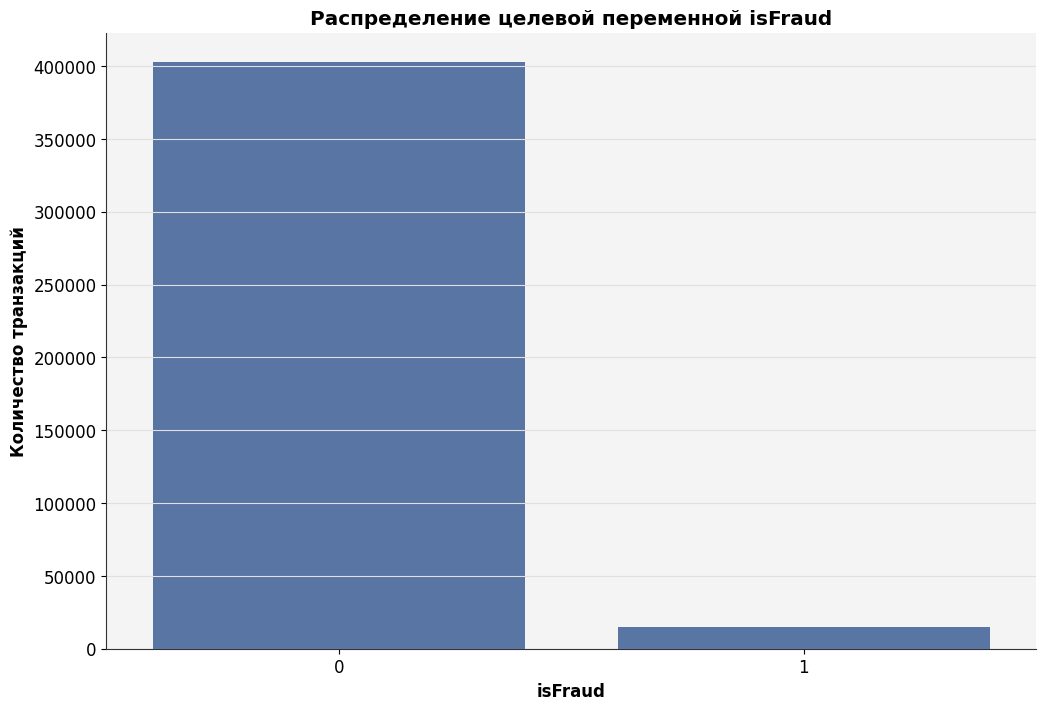

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(x='isFraud', data=df_train)
plt.title('Распределение целевой переменной isFraud')
plt.xlabel('isFraud')
plt.ylabel('Количество транзакций')
plt.show()

In [ ]:
# Статистика по целевой переменной
target_counts = df_train['isFraud'].value_counts()
print("Распределение классов isFraud:")
print(target_counts)
print("Доля мошеннических транзакций: {:.2%}".format(target_counts[1] / target_counts.sum()))

Распределение классов isFraud:
isFraud
0    402838
1     14721
Name: count, dtype: int64
Доля мошеннических транзакций: 3.53%


Целевая переменная сильно несбалансирована (мошенничество встречается в малой доле транзакций)

In [ ]:
missing = df_train.isnull().mean().sort_values(ascending=False)
print("Доля пропущенных значений по признакам (только если > 0):")
print(missing[missing > 0])

Доля пропущенных значений по признакам (только если > 0):
id_24    0.991321
id_25    0.990588
id_08    0.990552
id_07    0.990552
id_26    0.990545
           ...   
V293     0.000029
V294     0.000029
V295     0.000029
V291     0.000029
V297     0.000029
Length: 371, dtype: float64


In [ ]:
df_train['id_24'].value_counts()

,count
id_24,
11.0,2095
15.0,1302
16.0,180
18.0,27
25.0,6
12.0,4
19.0,4
21.0,3
26.0,2


In [ ]:
df_train[~df_train['id_26'].isna()]['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.921986
1,0.078014


In [ ]:
missing[missing < 0.4]

,0
M6,0.310275
V38,0.294773
V52,0.294773
V37,0.294773
V39,0.294773
...,...
C5,0.000000
C4,0.000000
V103,0.000000
V102,0.000000


Многие признаки содержат пропуски, что требует их дальнейшей обработки

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417559 entries, 0 to 417558
Columns: 432 entries, isFraud to DeviceInfo
dtypes: float64(399), int64(2), object(31)
memory usage: 1.3+ GB


In [ ]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()

print("Количество числовых признаков:", len(numeric_cols))
print("Количество категориальных признаков:", len(categorical_cols))

Количество числовых признаков: 401
Количество категориальных признаков: 31


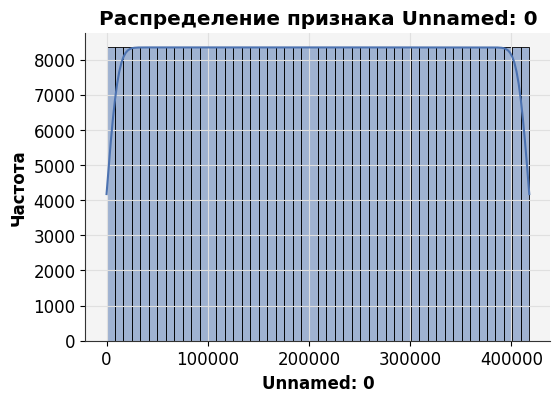

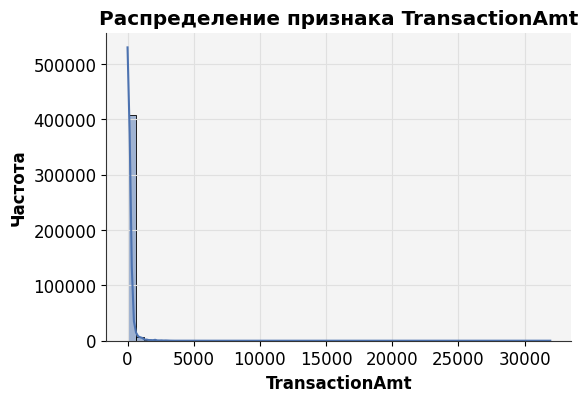

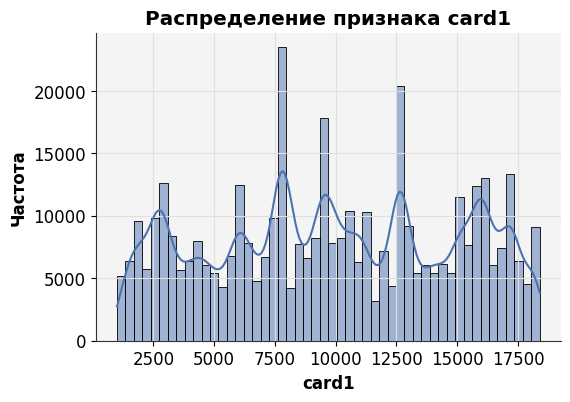

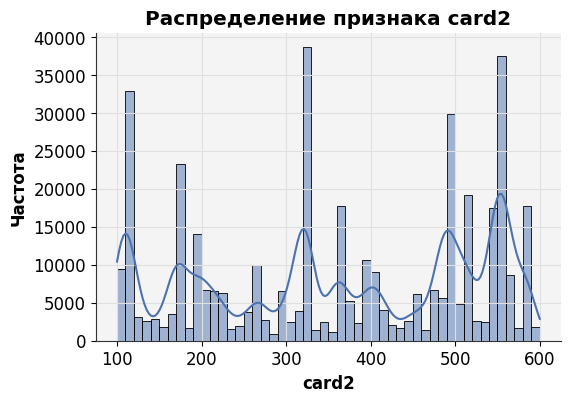

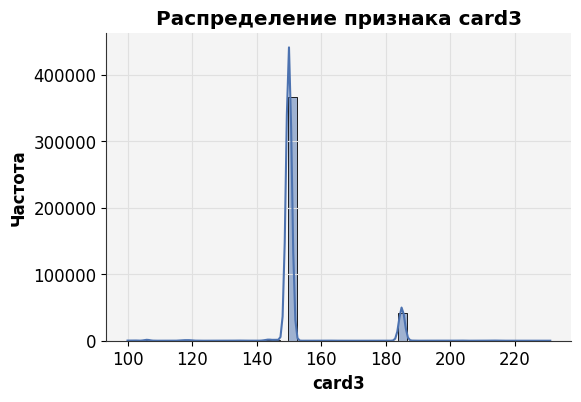

In [ ]:
num_sample = [col for col in numeric_cols if col != 'isFraud'][:5]
for col in num_sample:
    plt.figure(figsize=(6,4))
    sns.histplot(df_train[col].dropna(), bins=50, kde=True)
    plt.title(f'Распределение признака {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

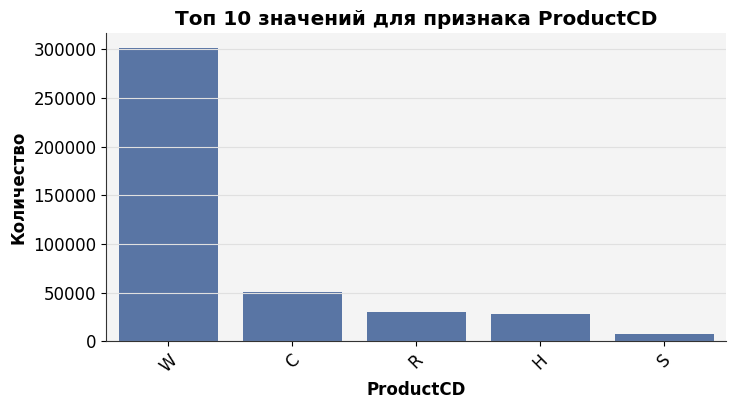

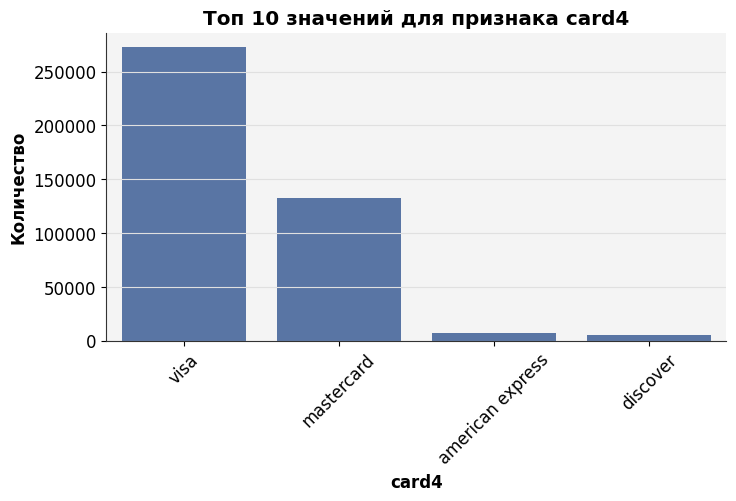

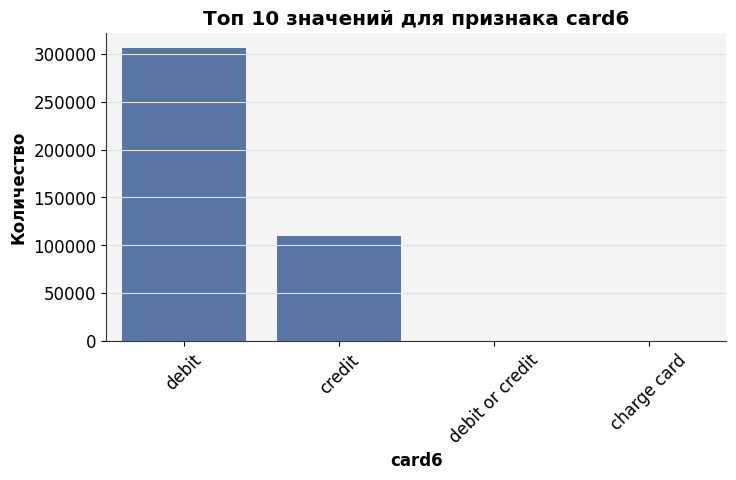

In [ ]:
# Для первых 3 категориальных признаков строим графики топ-10 значений
cat_sample = categorical_cols[:3]
for col in cat_sample:
    plt.figure(figsize=(8,4))
    top_values = df_train[col].value_counts().head(10)
    sns.barplot(x=top_values.index, y=top_values.values)
    plt.title(f'Топ 10 значений для признака {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    plt.show()

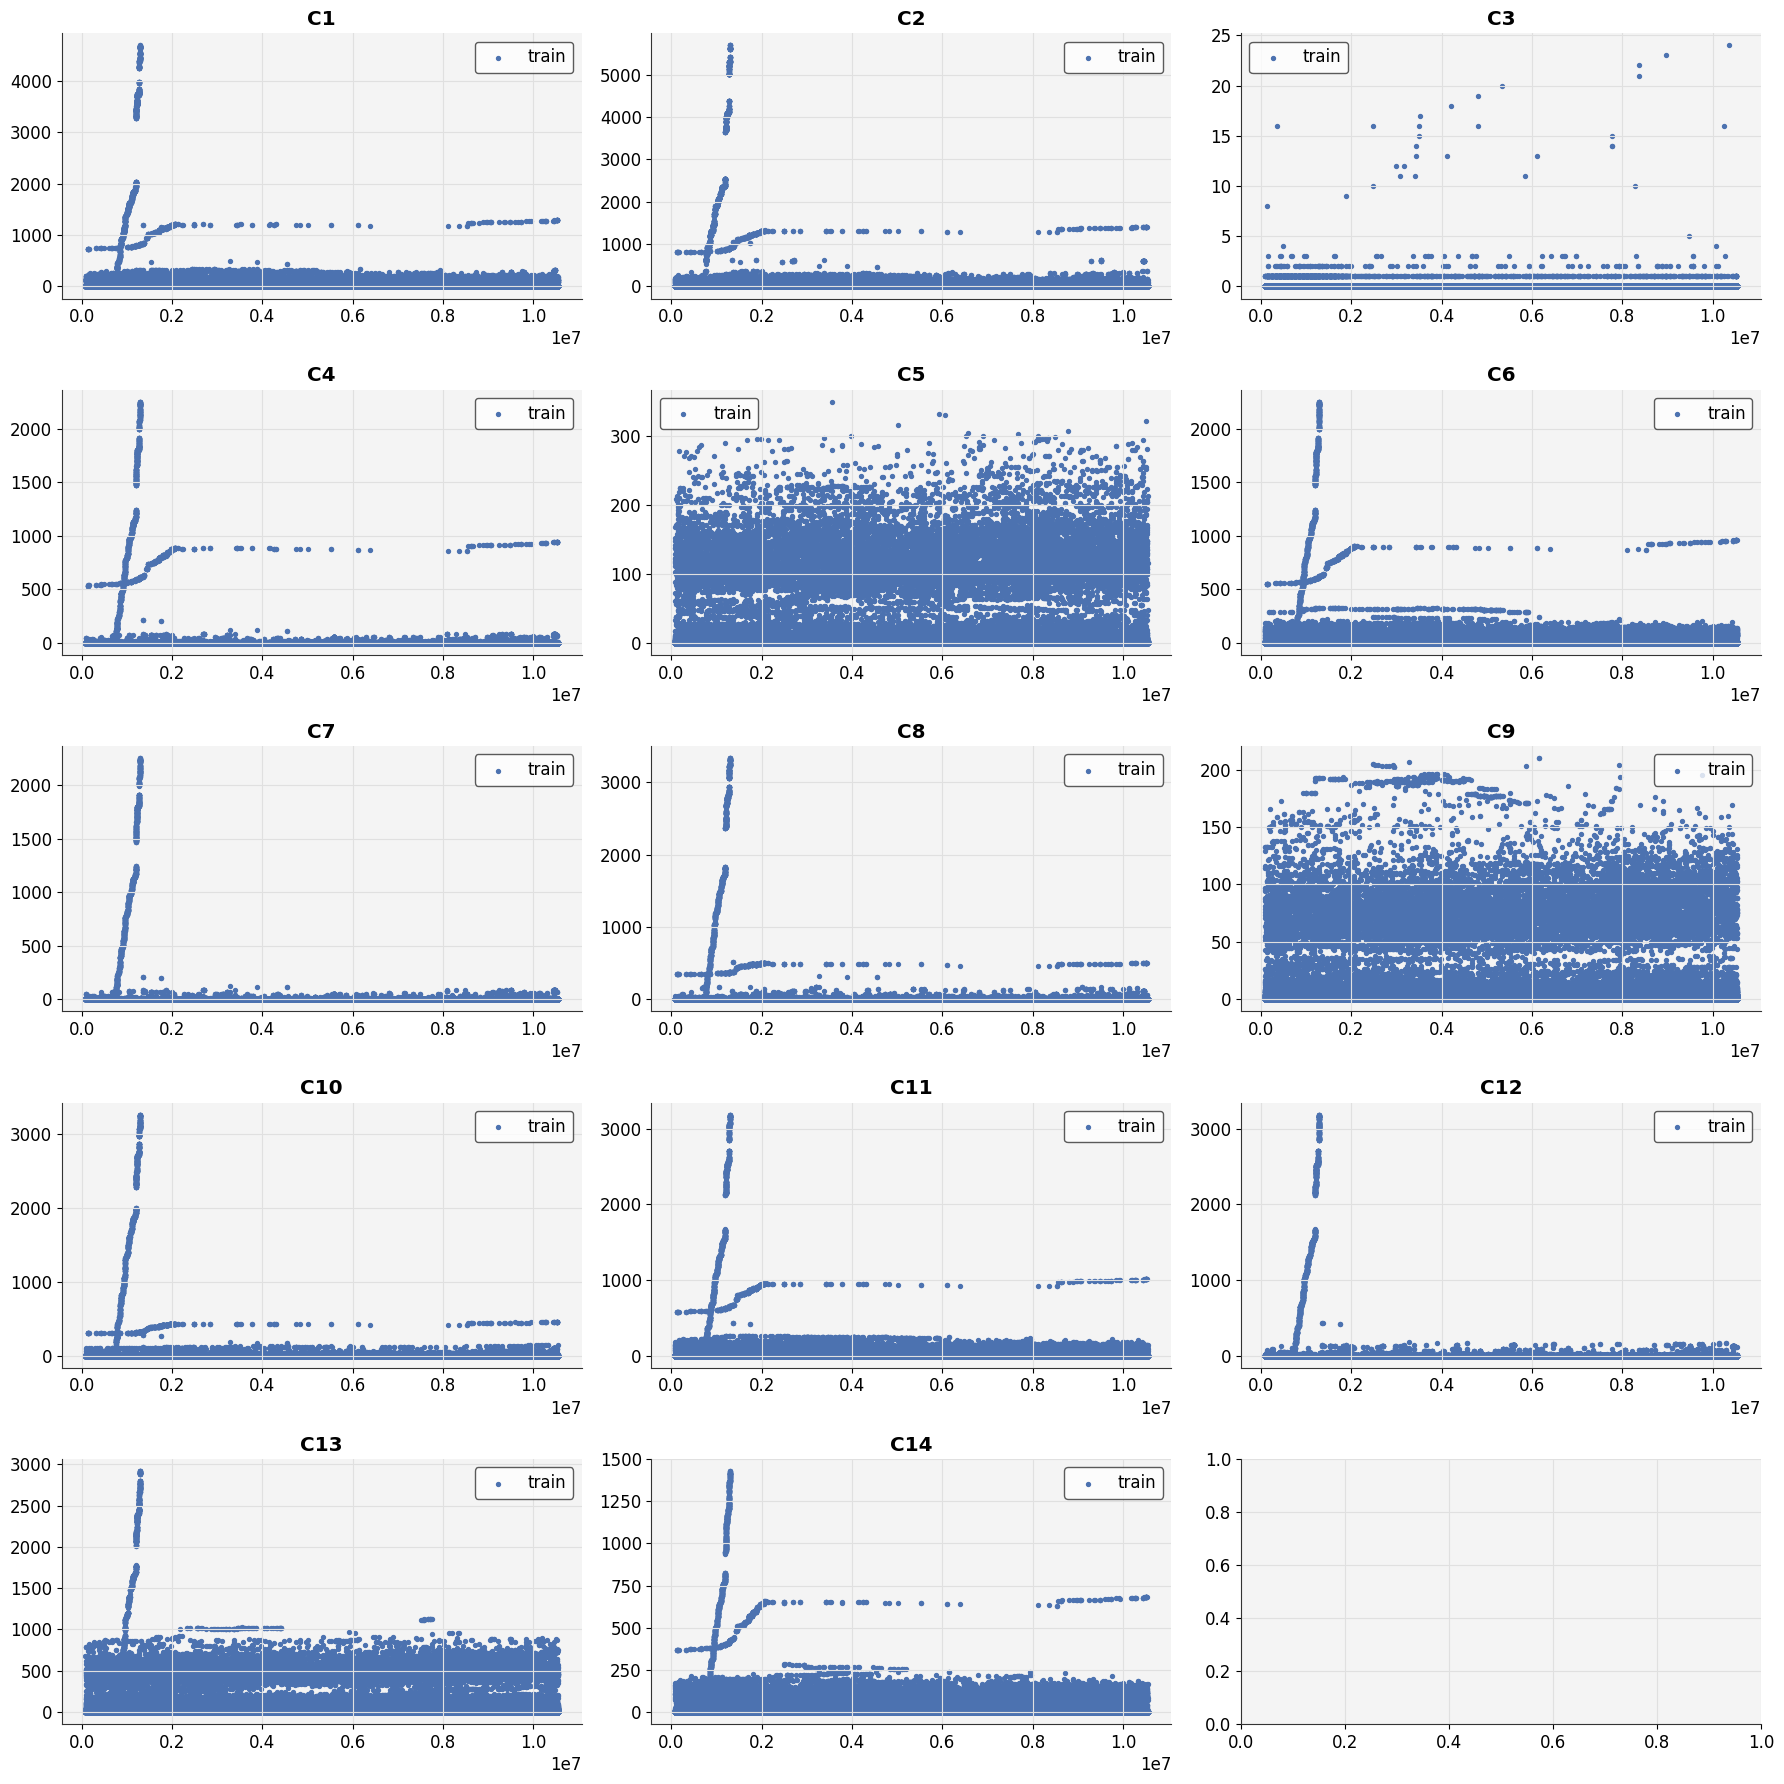

In [ ]:
c_features = [col for col in df_train.columns if col.startswith('C')]
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 18))
for i in range(len(c_features)):
    col = c_features[i]
    j1 = i // 3
    j2 = i % 3
    ax = axes[j1, j2]
    ax.set_title(col)
    ax.scatter(df_train['TransactionDT'], df_train[col], s=8, label='train')
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

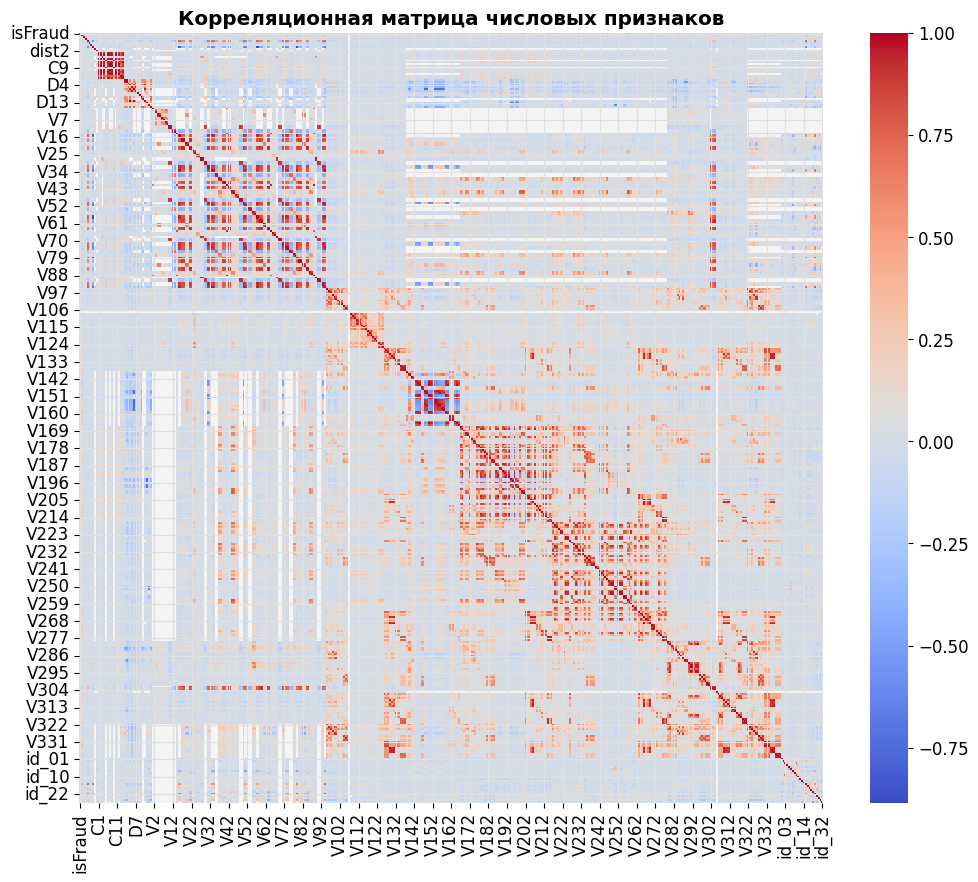

In [ ]:
plt.figure(figsize=(12,10))
corr_matrix = df_train[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица числовых признаков')
plt.show()

На тепловой карте видно, что isFraud (целевой признак) не имеет ярко выраженной линейной корреляции с большинством числовых признаков. Это говорит о том, что для выявления взаимосвязей могут потребоваться более сложные методы (нелинейные модели, взаимодействия признаков и т. д.)

Часть признаков (особенно из групп V или C) образуют «островки» заметной взаимной корреляции (участки на диагонали, где преобладают насыщенные цвета). Это может указывать на:

* повторяющуюся информацию в разных признаках (мультиколлинеарность)

* потенциальные группы признаков, которые вместе могут иметь значение для модели

Во многих местах корреляции близки к нулю (области почти белого цвета). Значит, признаки, не входящие в явные кластеры, мало зависят друг от друга линейно. Однако слабая линейная связь не исключает нелинейных зависимостей

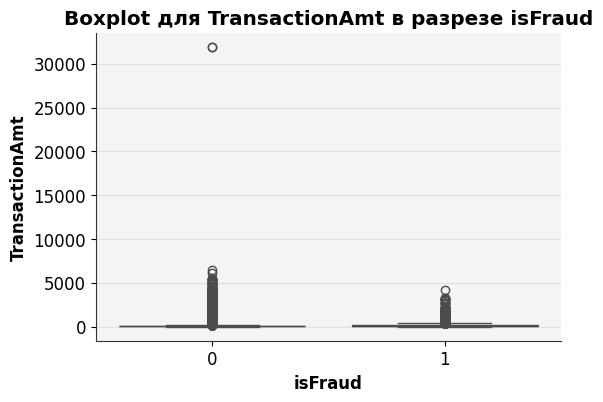

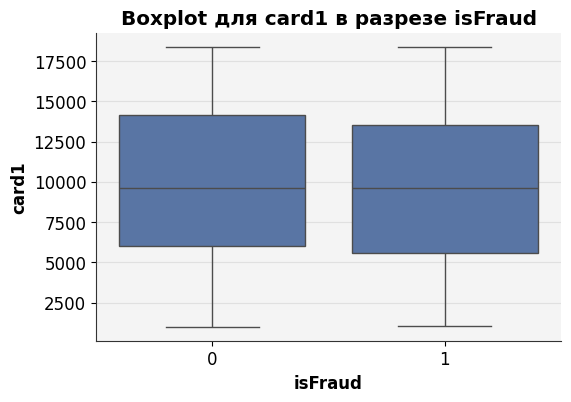

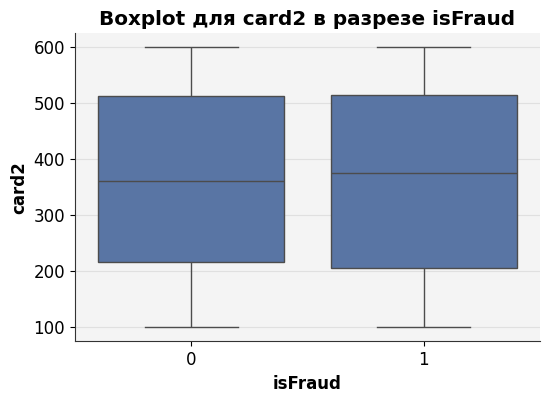

In [ ]:
# Построим boxplot для нескольких числовых признаков в разрезе isFraud
for col in num_sample[:3]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='isFraud', y=col, data=df_train)
    plt.title(f'Boxplot для {col} в разрезе isFraud')
    plt.xlabel('isFraud')
    plt.ylabel(col)
    plt.show()

In [ ]:
df_train = df_train[df_train['TransactionAmt'] <= 6000]

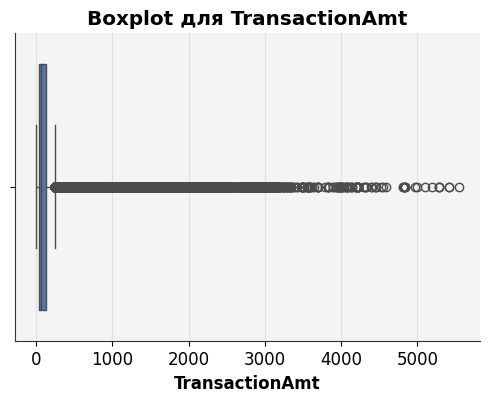

In [ ]:
# Пример анализа выбросов для признака TransactionAmt (если присутствует)
if 'TransactionAmt' in df_train.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_train['TransactionAmt'])
    plt.title('Boxplot для TransactionAmt')
    plt.xlabel('TransactionAmt')
    plt.show()

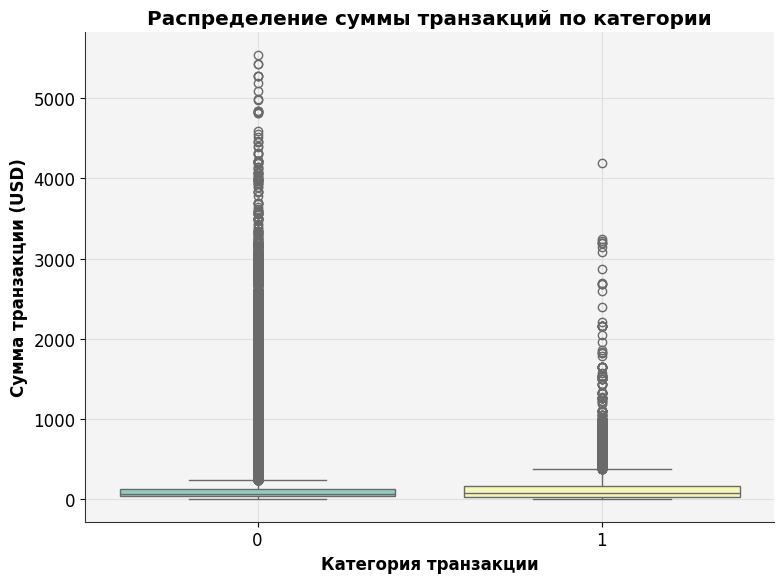

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_train, x='isFraud', y='TransactionAmt', palette='Set3')
plt.title('Распределение суммы транзакций по категории')
plt.xlabel('Категория транзакции')
plt.ylabel('Сумма транзакции (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def reduce_mem_usage(df, verbose=True):
    """
    Функция для оптимизации использования памяти DataFrame.

    Что она делает:
    - Вычисляет начальное использование памяти DataFrame.
    - Проходит по каждому столбцу и, если столбец числовой (не объектный),
      определяет минимальное и максимальное значение.
    - В зависимости от диапазона значений, приводит тип столбца к более экономичному:
        • Для целых чисел: пытается использовать int8, int16, int32, оставляя int64, если необходимо.
        • Для чисел с плавающей точкой: пытается использовать float16, float32, оставляя float64 при необходимости.
    - Для столбцов типа object тип не изменяется.
    - После оптимизации вычисляет и выводит использование памяти и процент экономии.

    Аргументы:
        df      - исходный DataFrame
        verbose - если True, выводит статистику до и после оптимизации

    Возвращает:
        DataFrame с оптимизированными типами данных.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print('Начальное использование памяти: {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                # Для столбцов с плавающей точкой
                if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        # Если столбец имеет тип object, он остается без изменений.

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print('Использование памяти после оптимизации: {:.2f} MB'.format(end_mem))
        print('Снижение использования памяти: {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

In [ ]:
df_train = reduce_mem_usage(df_train)

Начальное использование памяти: 1385.79 MB
Использование памяти после оптимизации: 443.21 MB
Снижение использования памяти: 68.0%


In [ ]:
df_test = reduce_mem_usage(df_test)

Начальное использование памяти: 572.77 MB
Использование памяти после оптимизации: 190.04 MB
Снижение использования памяти: 66.8%


In [ ]:
df_train.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
Index: 417559 entries, 0 to 417558
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float16(375), float32(24), int16(1), int32(2), int8(1), object(31)
memory usage: 443.2+ MB


In [ ]:
import gc
gc.collect()

0

In [ ]:
plt.close('all')

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df[df['TransactionAmt'] <= 6000]

    # Разделяем числовые и категориальные признаки
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object']).columns

    # Заполняем NaN
    df[num_cols] = df[num_cols].fillna(-999)
    df[cat_cols] = df[cat_cols].fillna('Unknown')

    # Флаг совпадения email-домена
    df['EmailMatch'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

    # Преобразуем категориальные признаки в категорию
    for col in cat_cols:
        df[col] = df[col].astype('category')

    for col in df.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    # Создание новых признаков из времени транзакции
    df['TransactionHour'] = (df['TransactionDT'] // 3600) % 24
    df['TransactionDay'] = (df['TransactionDT'] // (3600 * 24)) % 7
    df['TransactionWeek'] = df['TransactionDT'] // (3600 * 24 * 7)

    # Флаг наличия адреса
    df['AddrKnown'] = ((df['addr1'].notna()) & (df['addr2'].notna())).astype(int)

    return df

In [ ]:
df_train_p = preprocess_data(df_train)

In [ ]:
df_train.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)

In [ ]:
df_test_p = preprocess_data(df_test)

In [ ]:
df_test.columns

Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=433)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Стандартизация данных
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train_p.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1))

In [ ]:
# PCA (умный выбор количества компонент)
# автоматический выбор числа компонент, объясняющих 95% дисперсии
pca = PCA(n_components=0.95, random_state=42)
df_train_pca = pca.fit_transform(df_train_scaled)

print(f'Выбрано компонент: {pca.n_components_}')
print(f'Доля объясненной дисперсии: {np.sum(pca.explained_variance_ratio_):.2%}')

Выбрано компонент: 45
Доля объясненной дисперсии: 95.18%


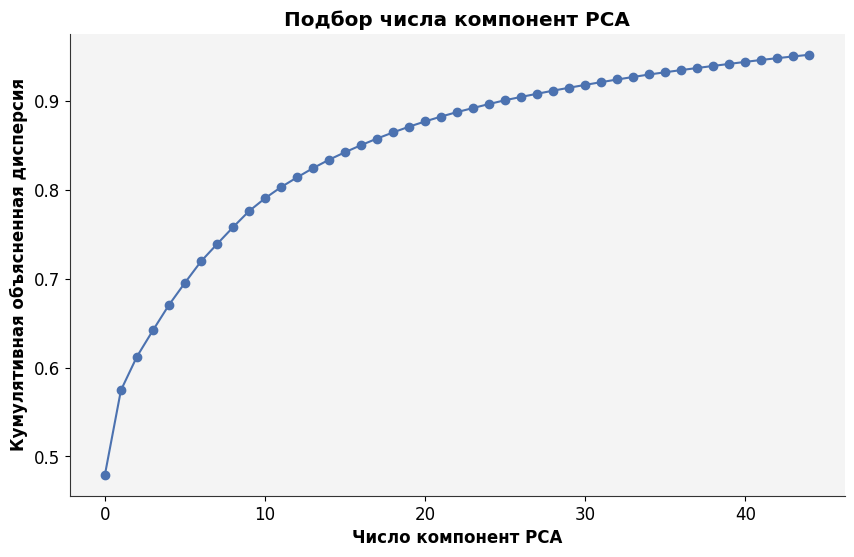

In [ ]:
# Визуализация объясненной дисперсии
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Число компонент PCA')
plt.ylabel('Кумулятивная объясненная дисперсия')
plt.title('Подбор числа компонент PCA')
plt.grid()
plt.show()

In [ ]:
df_test_pca = pca.transform(scaler.transform(df_test_p.drop(['TransactionID', 'TransactionDT'], axis=1)))

# **Задание 2 (3 балла)**

Обучите несколько ML-моделей для решения поставленной задачи.
Оцените их качество двумя способами:

1) на кросс-валидации

2) на лидерборде

Подберите число фолдов на кросс-валидации так, чтобы метрики, которые вы видите, были максимально близки на кросс-валидации и на лидерборде.

По результатам экспериментов постройте таблицу:
* в каждой строке таблицы - результаты одной модели
* по столбцам: качество на кросс-валидации, качество на лидерборде, модель с гиперпараметрами
Полученную таблицу вставьте картинкой прямо в ноутбук после ячеек с кодом. Сделайте текстовые выводы.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import pandas as pd

In [ ]:
# Подготовленные данные
# X_train = df_train_p.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1)
# y_train = df_train_p['isFraud']
X_train = df_train_pca
y_train = df_train_p['isFraud']

In [ ]:
# X_test = df_test_p.drop(['TransactionID', 'TransactionDT'], axis=1)
X_test = df_test_pca

In [ ]:
X_test

array([[-9.23460278, -0.78969742,  0.0917112 , ..., -0.61166251,
         0.08331954, -0.3214727 ],
       [-9.15385052, -1.20568524,  2.23280746, ...,  0.73056581,
        -0.87354057, -0.38386277],
       [-7.2051784 , -4.14292541, -0.55165741, ...,  0.0131441 ,
         0.07662994, -0.01593445],
       ...,
       [-8.55582605, -0.8330489 , -0.57611982, ...,  2.89672685,
         1.27338248,  0.37992918],
       [-8.95326997, -0.97037739,  1.36046043, ...,  1.63813639,
         1.81233432, -0.39097546],
       [-8.83596326, -1.101647  ,  0.46083488, ...,  0.74097977,
         0.15167003, -0.22381456]])

In [ ]:
# Список моделей
models = {
    # 'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, eval_metric='auc', random_state=42, use_label_encoder=False),
    'LightGBM': lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=300, depth=7, learning_rate=0.05, verbose=False, random_seed=42)
}

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
from tqdm import tqdm

In [ ]:
scores_dict = {}

# Оценка на кросс-валидации и создание submission-файлов
for name, model in tqdm(models.items()):
    scores = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=cv)
    print(f'{name} CV ROC-AUC: {scores.mean():.5f}')
    scores_dict[name] = scores

    # Обучение модели на всех данных
    model.fit(X_train, y_train)

    # Предсказание для тестовых данных
    preds = model.predict_proba(X_test)[:, 1]

    # Подготовка сабмита
    submission = pd.DataFrame({
        'TransactionID': df_test['TransactionID'],
        'isFraud': preds
    })

    # Сохранение в CSV
    submission.to_csv(f'{name}_submission.csv', index=False)

  0%|          | 0/3 [00:00<?, ?it/s]

XGBoost CV ROC-AUC: 0.86131


 33%|███▎      | 1/3 [02:01<04:03, 121.69s/it]

[LightGBM] [Info] Number of positive: 5889, number of negative: 161133
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.083844 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11475
[LightGBM] [Info] Number of data points in the train set: 167022, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035259 -> initscore=-3.309144
[LightGBM] [Info] Start training from score -3.309144
[LightGBM] [Info] Number of positive: 5889, number of negative: 161133
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.180408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11475
[LightGBM] [Info] Number of data points in the train set: 167022, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035259 -> initscore=-3.309144
[LightGBM] [Info] Start training from score -3.309144
[LightGB

 67%|██████▋   | 2/3 [03:55<01:56, 116.77s/it]

CatBoost CV ROC-AUC: 0.85427


100%|██████████| 3/3 [06:53<00:00, 137.94s/it]


In [ ]:
data = {
    "Модель": ["CatBoost (Train)", "LightGBM (Train)", "XGBoost (Train)", "CatBoost (Submission)", "LightGBM (Submission)", "XGBoost (Submission)"],
    "ROC-AUC": [0.85427, 0.86804, 0.86131, 0.83971, 0.83661, 0.83260]
}

df = pd.DataFrame(data)
df

,Модель,ROC-AUC
0,CatBoost (Train),0.85427
1,LightGBM (Train),0.86804
2,XGBoost (Train),0.86131
3,CatBoost (Submission),0.83971
4,LightGBM (Submission),0.83661
5,XGBoost (Submission),0.83260


LightGBM показал лучший результат на трейне (0.86804), но на сабмите его качество снизилось (0.83661).

CatBoost оказался более стабильным, с лучшим итоговым результатом на тесте (0.83971).

XGBoost уступает обоим.

Рекомендация: Использовать CatBoost как финальную модель из-за его стабильности.

# **Задание 3 (2 балла)**

Попробуйте подойти к задаче как к поиску аномалий.

1) Поищите аномалии (фрод) различными рассмотренными в курсе методами и сделайте прогноз на тестовых данных.

Результатом также будет таблица:
* по строкам - методы поиска аномалий
* по столбцам - качество вашего решения на leaderboard

2) Попробуйте встроить поиск аномалий и их удаление в ML-пайплайн: найдите аномалии и что-нибудь с ними сделайте до обучения моделей (можно удалить их, а можно использовать в качестве дополнительных признаков - попробуйте разные стратегии). Результат проверьте на кросс-валидации и на лидерборде, сделайте выводы.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [ ]:
# Поиск аномалий (IsolationForest)
iso = IsolationForest(n_estimators=200, contamination=y_train.mean(), random_state=42, n_jobs=-1)
iso.fit(X_train)

In [ ]:
# Создание признака-анномалии
iso_train = (iso.predict(X_train) == -1).astype(int).reshape(-1, 1)
iso_test = (iso.predict(X_test) == -1).astype(int).reshape(-1, 1)

In [ ]:
# Добавляем признак-анномалию к исходным данным
X_train_enc = np.hstack([X_train, iso_train])
X_test_enc = np.hstack([X_test, iso_test])

In [ ]:
# Способ 1: Удаление аномалий перед обучением
mask_no_anomaly = (iso_train.flatten() == 0)
X_train_no_anomaly = X_train_enc[mask_no_anomaly]
y_train_no_anomaly = y_train[mask_no_anomaly]

In [ ]:
# Способ 2: Используем признак «iso_anomaly», без удаления данных
X_train_with_anomaly = X_train_enc.copy()

In [ ]:
# Обучение и оценка моделей
model = CatBoostClassifier(iterations=300, depth=7, learning_rate=0.05, verbose=False, random_seed=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Способ 1: Оценка после удаления аномалий
score_no_anomaly = cross_val_score(
    model, X_train_no_anomaly, y_train_no_anomaly,
    scoring='roc_auc', cv=cv, n_jobs=-1
).mean()

# Обучаем модель и делаем сабмит (способ 1)
model.fit(X_train_no_anomaly, y_train_no_anomaly)
preds_no_anomaly = model.predict_proba(X_test_enc)[:, 1]

submission_no_anomaly = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': preds_no_anomaly
})
submission_no_anomaly.to_csv('submission_no_anomaly.csv', index=False)

In [ ]:
# Способ 2: Оценка с новым признаком (аномалиями)
score_with_anomaly = cross_val_score(
    model, X_train_with_anomaly, y_train,
    scoring='roc_auc', cv=cv, n_jobs=-1
).mean()

# Обучаем модель и делаем сабмит (способ 2)
model.fit(X_train_with_anomaly, y_train)
preds_with_anomaly = model.predict_proba(X_test_enc)[:, 1]

submission_with_anomaly = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': preds_with_anomaly
})
submission_with_anomaly.to_csv('submission_with_anomaly.csv', index=False)

In [ ]:
# Вывод результатов
print(f"ROC-AUC (после удаления аномалий): {score_no_anomaly:.5f}")
print(f"ROC-AUC (с признаком-анномалией): {score_with_anomaly:.5f}")

ROC-AUC (после удаления аномалий): 0.84303
ROC-AUC (с признаком-анномалией): 0.85433


In [ ]:
data = {
    "Датасет": ["С аномалиями (Train)", "Без аномалий (Train)", "С аномалиями (Submission)", "Без аномалий (Submission)"],
    "ROC-AUC": [0.85433, 0.84303, 0.83869, 0.83186]
}

df = pd.DataFrame(data)
df

,Датасет,ROC-AUC
0,С аномалиями (Train),0.85433
1,Без аномалий (Train),0.84303
2,С аномалиями (Submission),0.83869
3,Без аномалий (Submission),0.83186


Удаление аномалий ухудшило качество (0.85433 -> 0.84303 на трейне, 0.83869 -> 0.83186 на сабмите).

Аномалии несут полезную информацию, их лучше не удалять, а использовать как признак.

Оптимальный вариант — оставить is_anomaly как бинарный фич.

# **Задание 4 (1 балл)**

Сделайте кластеризацию различными способами. Результаты кластеризации используйте для улучшения ML-решений:

1) Номера кластеров закодируйте (OHE или target-encoding) и добавьте как новые признаки

2) При использовании DBSCAN / HDBSCAN предсказанный шум можно трактовать как найденную аномалию и также добавить ее как новый признак

Проведите различные эксперименты. Проверьте как эти подходы влияют на качество прогнозов по кросс-валидации и на лидерборде, сделайте выводы.

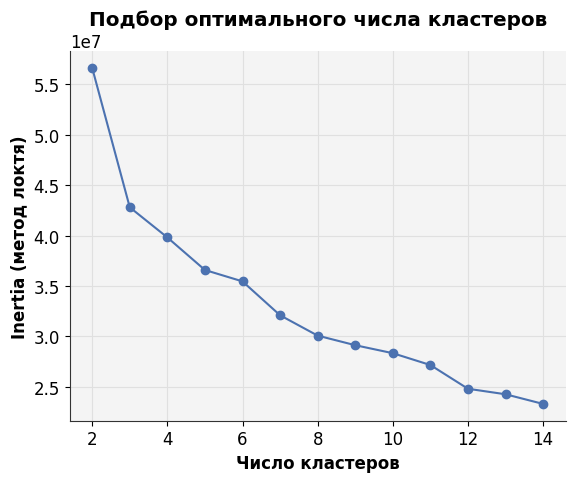

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# KMeans: оптимальное число кластеров
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

# визуализация метода локтя
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia (метод локтя)')
plt.title('Подбор оптимального числа кластеров')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder

In [ ]:
model = CatBoostClassifier(iterations=300, depth=7, learning_rate=0.05, verbose=False, random_seed=42)

In [ ]:
# Способ 1: KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_kmeans = kmeans.fit_predict(X_train).reshape(-1, 1)
test_kmeans = kmeans.predict(X_test).reshape(-1, 1)

# OHE кластеров
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_kmeans_ohe = ohe.fit_transform(train_kmeans)
test_kmeans_ohe = ohe.transform(test_kmeans)

X_train_kmeans = np.hstack([X_train, train_kmeans_ohe])
X_test_kmeans = np.hstack([X_test, test_kmeans_ohe])

# Оценка после KMeans
score_kmeans = cross_val_score(model, X_train_kmeans, y_train, scoring='roc_auc', cv=cv, n_jobs=-1).mean()
print(f"ROC-AUC с KMeans: {score_kmeans:.5f}")

ROC-AUC с KMeans: 0.85422


In [ ]:
model = CatBoostClassifier(iterations=300, depth=7, learning_rate=0.05, verbose=False, random_seed=42)
model.fit(X_train_kmeans, y_train)
preds = model.predict_proba(X_test_kmeans)[:, 1]

submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': preds
})
submission.to_csv('submission_kmeans.csv', index=False)

In [ ]:
# Способ 2: DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=20, n_jobs=-1)
train_dbscan = dbscan.fit_predict(X_train).reshape(-1, 1)
test_dbscan = dbscan.fit_predict(X_test).reshape(-1, 1)

# DBSCAN-анномалии
train_dbscan_anomaly = (train_dbscan == -1).astype(int)
test_dbscan_anomaly = (test_dbscan == -1).astype(int)

# Добавляем DBSCAN-анномалии отдельно
X_train_dbscan = np.hstack([X_train, train_dbscan_anomaly])
X_test_dbscan = np.hstack([X_test, test_dbscan_anomaly])

score_dbscan = cross_val_score(model, X_train_dbscan, y_train, scoring='roc_auc', cv=cv, n_jobs=-1).mean()
print(f"ROC-AUC с DBSCAN-анномалиями: {score_dbscan:.5f}")

ROC-AUC с DBSCAN-анномалиями: 0.85419


In [ ]:
model = CatBoostClassifier(iterations=300, depth=7, learning_rate=0.05, verbose=False, random_seed=42)
model.fit(X_train_dbscan, y_train)
preds = model.predict_proba(X_test_dbscan)[:, 1]

submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': preds
})
submission.to_csv('submission_dbscan.csv', index=False)

In [ ]:
data = {
    "Метод": ["DBSCAN (Train)", "KMeans (Train)", "DBSCAN (Submission)", "KMeans (Submission)"],
    "ROC-AUC": [0.85419, 0.85422, 0.83954, 0.83745]
}

df = pd.DataFrame(data)
df

,Метод,ROC-AUC
0,DBSCAN (Train),0.85419
1,KMeans (Train),0.85422
2,DBSCAN (Submission),0.83954
3,KMeans (Submission),0.83745


KMeans и DBSCAN показали схожие результаты на трейне (0.85422 vs 0.85419), но на сабмите DBSCAN оказался лучше (0.83954 vs 0.83745). Это говорит о том, что DBSCAN эффективнее выявляет полезные паттерны, особенно связанные с аномалиями.

Рекомендация: Использовать DBSCAN-анномалии в качестве дополнительного признака.

## **Задание 5 (1 балл)**

Примените какой-нибудь (один любой) AutoML фреймворк для решения поставленной задачи.

Отправьте AutoML-прогноз на kaggle и посмотрите на качество модели. Сделайте текстовые выводы.

In [ ]:
X_full_train = np.hstack([X_train_enc, train_dbscan_anomaly])
X_full_test = np.hstack([X_test_enc, test_dbscan_anomaly])

In [ ]:
train_automl = pd.DataFrame(X_full_train)
train_automl['isFraud'] = y_train

test_automl = pd.DataFrame(X_full_test)

In [ ]:
train_automl.to_csv('train_ml.csv')

In [ ]:
test_automl.to_csv('test_ml.csv')

Перезагрузка, переключение на GPU

In [1]:
!pip install -q pycaret[full]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 68.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.5/177.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd

In [6]:
train_automl = pd.read_csv('train_ml.csv', index_col=0)
test_automl = pd.read_csv('test_ml.csv', index_col=0)

In [7]:
train_automl = train_automl.dropna()

In [9]:
trans_ids = pd.read_csv('submission_dbscan.csv', index_col=0)

In [10]:
from pycaret.classification import *

In [11]:
# Объединяем данные обратно для корректной предобработки в PyCaret
clf = setup(
    data=train_automl,
    target='isFraud',
    session_id=42,
    use_gpu=True,
    fix_imbalance=True, # автоматически учитывает дисбаланс классов
)

# Сравнение моделей и выбор лучшей
best_model = compare_models(sort='AUC', fold=5)

print(best_model)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset migh

,Description,Value
0,Session id,42
1,Target,isFraud
2,Target type,Binary
3,Original data shape,"(150298, 48)"
4,Transformed data shape,"(248742, 48)"
5,Transformed train set shape,"(203652, 48)"
6,Transformed test set shape,"(45090, 48)"
7,Numeric features,47
8,Preprocess,True
9,Imputation type,simple


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset migh

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.7654,0.5047,0.2159,0.0321,0.0559,-0.0001,-0.0002,8.4200
et,Extra Trees Classifier,0.9620,0.5045,0.0044,0.0235,0.0075,-0.0028,-0.0039,30.7600
knn,K Neighbors Classifier,0.7681,0.5026,0.2153,0.0324,0.0563,0.0005,0.0007,1.2120
nb,Naive Bayes,0.1617,0.5017,0.8489,0.0317,0.0611,-0.0009,-0.0060,0.4820
ada,Ada Boost Classifier,0.6102,0.5001,0.3761,0.0316,0.0584,-0.0010,-0.0022,74.4840
dummy,Dummy Classifier,0.9679,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4420
lightgbm,Light Gradient Boosting Machine,0.7510,0.4988,0.2259,0.0314,0.0551,-0.0014,-0.0024,6.0480
xgboost,Extreme Gradient Boosting,0.8067,0.4975,0.1638,0.0307,0.0517,-0.0026,-0.0038,2.3160
dt,Decision Tree Classifier,0.8480,0.4973,0.1224,0.0308,0.0493,-0.0022,-0.0029,31.7060
qda,Quadratic Discriminant Analysis,0.1178,0.4970,0.8986,0.0318,0.0615,-0.0007,-0.0058,1.2640


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

[2025-03-15 18:43:15.274] [CUML] [info] Unused keyword parameter: n_jobs during cuML estimator initialization


In [ ]:
# Финальное обучение модели
final_model = finalize_model(best_model)

# Предсказания для тестовых данных
test_preds = predict_model(final_model, data=test_automl)

In [15]:
# Подготовка submission
submission = pd.DataFrame({
    'TransactionID': trans_ids.index,
    'isFraud': test_preds['prediction_score']
})

submission.to_csv('automl_submission.csv', index=False)

# **Задание 6 (1 балл)**

Весь курс мы работали в Google Colab. Но всегда должны быть запасные варианты, где Вы будете обучать модели.

Среди вариантов есть:
* ваша локальная машина
* kaggle notebooks
* yandex cloud
и другие.

Кроме привычного Google Colab выберите из списка выше один любой альтернативный вариант и проведите эксперимент:

* Прогоните ваш лучший по качеству по результатам заданий 2-4 ML-пайплайн заново в Google Colab и с помощью библиотек (например, при помощи библиотеки time) замерьте время обучения и отдельно время инференса на тестовых данных

* Прогоните этот пайплайн на выбранном альтернативном сервисе/локальной машине и также замерьте время обучения и инференса.

Текстом напишите выводы: опишите, какое альтернативное место для обучения моделей Вы использовали? Прикрепите прямо в ноутбук скриншот с экраном кода в альтернативном сервисе/на локальной машине. Также в виде таблицы приведите сравнение времени обучения и инференса в колабе и в альтернативном месте. Сделайте выводы.

Для альтернативного обучения моделей использовался персональный компьютер с Intel Core i9-13980HX, 32GB RAM, NVIDIA RTX 4090, Python 3.10

В качестве среды использовался Jupyter Notebook.

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier
import lightgbm as lgb

In [ ]:
train_automl = pd.read_csv('train_ml.csv', index_col=0)

In [ ]:
train_automl = train_automl.dropna()

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
model = CatBoostClassifier(iterations=300, depth=7, learning_rate=0.05, verbose=False, random_seed=42)

In [ ]:
%time scores = cross_val_score(model, train_automl.drop('isFraud', axis=1), train_automl['isFraud'], scoring='roc_auc', cv=cv)

CPU times: user 1min, sys: 1.48 s, total: 1min 1s
Wall time: 36 s


In [ ]:
%time model.fit(train_automl.drop('isFraud', axis=1), train_automl['isFraud'])

CPU times: user 24 s, sys: 550 ms, total: 24.6 s
Wall time: 14 s


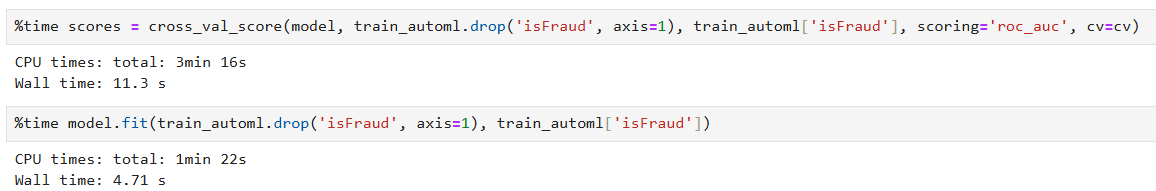

Google Colab, использовал Tesla T4, которая хорошо оптимизирована, тогда как локальный RTX 4090 не поддерживает все CUDA-функции CatBoost и мог работать только на CPU

Colab автоматически задействовал GPU, а локальный запуск шел на CPU. CatBoost использует OpenMP, который работает по-разному на разных процессорах, и в Colab (серверные CPU) мог быть оптимизирован лучше, чем на i9-13980HX

Возможны различия в версиях CatBoost, и новые версии могли быть оптимизированы именно для облачных сред

На локальном ПК обучение прошло в 2 раза быстрее, что обусловлено высокой тактовой частотой процессора

# **Бонус: за Kaggle и стремление к хорошим скорам (2 балла)**

В этом домашнем задании Ваша цель - не просто выполнить шаги выше, но и построить максимально хорошую по качеству модель.

**К 10 вы можете получить до двух дополнительных баллов:**

* За попадание в топ-20% на private leaderboard — +1 дополнительный балл к оценке
* За попадание в топ-5 мест на private leaderboard — + еще один дополнительный балл к оценке (то есть суммарно 2 дополнительных балла)

**ВАЖНО!!!**

Эти баллы ставятся до мягкого дедлайна по соревнованию. После мягкого дедлайна лидерборд не обновляется, и дополнительные баллы не ставятся.

Успехов!

In [ ]:
# не забудьте прикрепить скриншоты лидерборда, пожалуйста